In [12]:
from PIL import Image
import pathlib
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

In [17]:
parent_directory = pathlib.Path.cwd().parent

drowsy_image_path = parent_directory / "data" / "raw" / "Driver Drowsiness Dataset (DDD)" / "Drowsy" / "A0095.png"
non_drowsy_image_path = parent_directory / "data" / "raw" / "Driver Drowsiness Dataset (DDD)" / "Non Drowsy" / "a0077.png"

In [18]:
drowsy_image_path

WindowsPath('g:/Driver Drowsiness Detection/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0095.png')

In [19]:
drowsy_images = []
non_drowsy_images = []

drowsy_image = Image.open(drowsy_image_path)
non_drowsy_image = Image.open(non_drowsy_image_path)

upper_drowsy_part = drowsy_image.crop((0,0,227,110))
lower_drowsy_part = drowsy_image.crop((0,130,227,227))

upper_nondrowsy_part = non_drowsy_image.crop((0,0,227,110))
lower_nondrowsy_part = non_drowsy_image.crop((0,130,227,227))

drowsy_images.append(drowsy_image)
drowsy_images.append(upper_drowsy_part)
drowsy_images.append(lower_drowsy_part)

non_drowsy_images.append(non_drowsy_image)
non_drowsy_images.append(upper_nondrowsy_part)
non_drowsy_images.append(lower_nondrowsy_part)

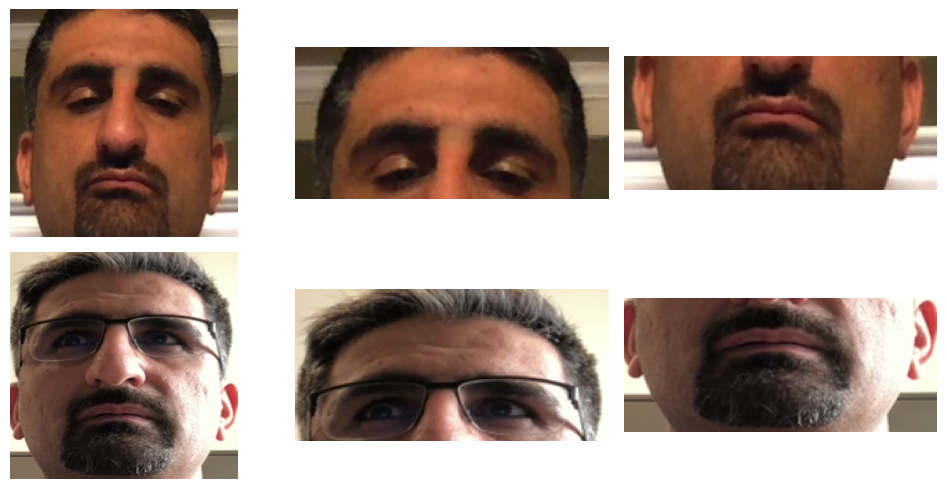

In [20]:
fig,axes = plt.subplots(nrows = 2,ncols = 3,figsize=(10,5))
for i, axis in enumerate(axes):
    for idx,j in enumerate(axis):
        if i == 0:
            j.imshow(drowsy_images[idx])
            j.axis("off")
        if i == 1:
            j.imshow(non_drowsy_images[idx])
            j.axis("off")
plt.tight_layout()

In [67]:
drowsy_array = np.asarray(drowsy_image)

In [68]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True,max_num_faces=1)

results = face_mesh.process(drowsy_array)
face_landmarks = results.multi_face_landmarks[0]
len(face_landmarks.landmark)


g:\Driver Drowsiness Detection\myenv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


468

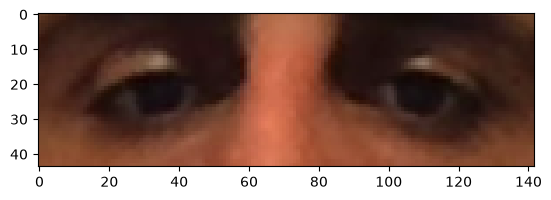

In [85]:
left_eye = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
right_eye = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]
mouth = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 88, 95]

left_x = []
left_y = []
right_x = []
right_y = []
mouth_x = []
mouth_y = []


landmarks = face_landmarks.landmark

for i in left_eye:
    left_x.append(landmarks[i].x * drowsy_image.size[0])
    left_y.append(landmarks[i].y * drowsy_image.size[1])

for i in right_eye:
    right_x.append(landmarks[i].x * drowsy_image.size[0])
    right_y.append(landmarks[i].y * drowsy_image.size[1])

for i in mouth:
    mouth_x.append(landmarks[i].x * drowsy_image.size[0])
    mouth_y.append(landmarks[i].y * drowsy_image.size[1])
   
eyes_x = left_x + right_x
eyes_y = left_y + right_y

padding = 15

eye_crop = drowsy_image.crop((min(eyes_x)-padding,min(eyes_y)-padding,max(eyes_x)+padding,max(eyes_y)+padding))
mouth_crop = drowsy_image.crop((min(mouth_x)-padding,min(mouth_y)-padding,max(mouth_x)+padding,max(mouth_y)+padding))
plt.imshow(eye_crop)

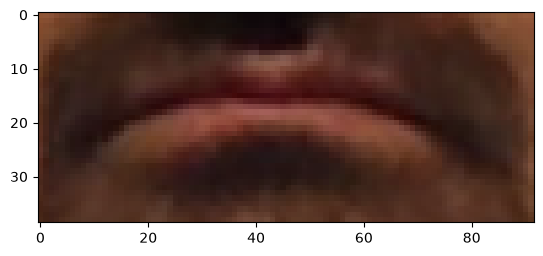

In [86]:
plt.imshow(mouth_crop)